# Data Analysis and Visualization


In [21]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display


In [22]:
# Root-relative or absolute compare-output directories. These are the only two data inputs!
SAFETY_NAS_DATA_DIR: Path | str = "safety-nas/compare-map-150"
ACCURACY_NAS_DATA_DIR: Path | str = "accuracy-nas/compare-map-150"

In [23]:

def _notebook_dir() -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parent

    vscode_notebook = globals().get("__vsc_ipynb_file__")
    if vscode_notebook:
        return Path(vscode_notebook).expanduser().resolve().parent

    cwd = Path.cwd().resolve()
    if (cwd / "visualizations" / "vis.ipynb").exists():
        return cwd / "visualizations"
    return cwd


NOTEBOOK_DIR = _notebook_dir()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "visualizations" else NOTEBOOK_DIR

def resolve_data_dir(path_like: Path | str) -> Path:
    raw_path = Path(path_like).expanduser()
    candidates = [raw_path] if raw_path.is_absolute() else [REPO_ROOT / raw_path, NOTEBOOK_DIR / raw_path]
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists() and any(candidate.glob("*/metrics.jsonl")):
            return candidate
    tried = [candidate.resolve() for candidate in candidates]
    raise FileNotFoundError(
        f"No metrics.jsonl run directories found for {path_like!r}. Tried: {tried}"
    )


SAFETY_NAS_OUTPUT_DIR = resolve_data_dir(SAFETY_NAS_DATA_DIR)
ACCURACY_NAS_OUTPUT_DIR = resolve_data_dir(ACCURACY_NAS_DATA_DIR)

# Backward-compatible aliases used by the plotting helpers below.
BASE_OUTPUT_DIR = ACCURACY_NAS_OUTPUT_DIR
SECONDARY_BASE_OUTPUT_DIR = SAFETY_NAS_OUTPUT_DIR

print(f"Using Safety-NAS compare output directory: {SAFETY_NAS_OUTPUT_DIR}")
print(f"Using Accuracy-NAS compare output directory: {ACCURACY_NAS_OUTPUT_DIR}")


BASELINE_LABEL = "Baseline"
SAFETY_NAS_LABEL = "Safety-NAS"
ACCURACY_NAS_LABEL = "Accuracy-NAS"
MODEL_GROUP_ORDER = [BASELINE_LABEL, SAFETY_NAS_LABEL, ACCURACY_NAS_LABEL]
MODEL_FAMILY_ORDER = [SAFETY_NAS_LABEL, ACCURACY_NAS_LABEL]


def model_family_for_run_dir(run_dir: Path) -> str:
    run_dir = resolve_compare_run_dir(run_dir)
    if run_dir.parent.resolve() == ACCURACY_NAS_OUTPUT_DIR.resolve():
        return ACCURACY_NAS_LABEL
    if run_dir.parent.resolve() == SAFETY_NAS_OUTPUT_DIR.resolve():
        return SAFETY_NAS_LABEL
    return run_dir.parent.name


def model_family_for_run_id(run_id: str) -> str:
    return model_family_for_run_dir(resolve_compare_run_dir(run_id))


def model_display_name(run_id: str) -> str:
    family = model_family_for_run_id(run_id)
    if family == SAFETY_NAS_LABEL:
        return f"{SAFETY_NAS_LABEL} ({TRAINED_MAP_LABELS.get(run_id, run_id)})" if "TRAINED_MAP_LABELS" in globals() else f"{SAFETY_NAS_LABEL} ({run_id})"
    if family == ACCURACY_NAS_LABEL:
        return ACCURACY_NAS_LABEL
    return run_id


def latest_run_dir(base_dir: Path = ACCURACY_NAS_OUTPUT_DIR) -> Path:
    candidates = sorted(
        [path for path in base_dir.glob("*/metrics.jsonl")],
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No metrics.jsonl files found under {base_dir}. Run accuracy-nas/compare-track.py first."
        )
    return candidates[-1].parent

# Set this to a run directory name to pin one Accuracy-NAS comparison run.
RUN_DIR_OVERRIDE: Path | str | None = None


def resolve_run_dir() -> Path:
    if RUN_DIR_OVERRIDE:
        candidate = Path(RUN_DIR_OVERRIDE)
        if not candidate.is_absolute():
            candidate = ACCURACY_NAS_OUTPUT_DIR / candidate
        if candidate.is_file():
            candidate = candidate.parent
        if not candidate.exists():
            raise FileNotFoundError(
                f"Override directory {candidate} was not found. Update RUN_DIR_OVERRIDE."
            )
        metrics_file = candidate / "metrics.jsonl"
        if not metrics_file.exists():
            raise FileNotFoundError(
                f"{metrics_file} was not found; choose a directory containing metrics.jsonl."
            )
        return candidate
    return latest_run_dir()

RUN_DIR = resolve_run_dir()
METRICS_FILE = RUN_DIR / "metrics.jsonl"
print(f"Using Accuracy-NAS metrics from: {RUN_DIR}")

with METRICS_FILE.open("r", encoding="utf-8") as fh:
    METRIC_RECORDS = [json.loads(line) for line in fh if line.strip()]

if not METRIC_RECORDS:
    raise RuntimeError(f"{METRICS_FILE} is empty; rerun compare-track.")

def display_map_name(map_name: str) -> str:
    return Path(map_name).name


rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        rows.append(
            {
                "map": map_name,
                "map_label": display_map_name(map_name),
                "arch": run["label"],
                "rmse": run.get("rmse"),
            }
        )

df = pd.DataFrame(rows)
pivot = df.pivot_table(index="arch", columns="map_label", values="rmse")
pivot = pivot.sort_index()

def default_highlight_arch(index: pd.Index) -> str | None:
    for candidate in (RUN_DIR.name, "arch8"):
        if candidate in index:
            return candidate
    return None


HIGHLIGHT_ARCH = default_highlight_arch(pivot.index)
print(f"Loaded RMSE table with shape {pivot.shape} (arches x maps).")


Using Safety-NAS compare output directory: /Users/zayahcortright/Desktop/all.nosync/git.nosync/NAS-in-the-Loop/safety-nas/compare-map-150
Using Accuracy-NAS compare output directory: /Users/zayahcortright/Desktop/all.nosync/git.nosync/NAS-in-the-Loop/accuracy-nas/compare-map-150
Using Accuracy-NAS metrics from: /Users/zayahcortright/Desktop/all.nosync/git.nosync/NAS-in-the-Loop/accuracy-nas/compare-map-150/262e4c
Loaded RMSE table with shape (8, 7) (arches x maps).


### Metric Setup

In [24]:
metric_specs = {
    "crosstrack_rmse_m": {
        "title": "Cross-track RMSE",
        "ylabel": "Cross-track RMSE (m)",
        "table_title": "Cross-track RMSE (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_mean_m": {
        "title": "Mean cross-track error",
        "ylabel": "Mean cross-track error (m)",
        "table_title": "Mean cross-track error (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_std_m": {
        "title": "Cross-track variability",
        "ylabel": "Cross-track std (m)",
        "table_title": "Cross-track std (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_max_m": {
        "title": "Maximum cross-track error",
        "ylabel": "Max cross-track error (m)",
        "table_title": "Max cross-track error (m)",
        "ylim_bottom": 0.0,
    },
    "heading_error_rmse_deg": {
        "title": "Heading-error RMSE",
        "ylabel": "Heading-error RMSE (deg)",
        "table_title": "Heading-error RMSE (deg)",
        "ylim_bottom": 0.0,
    },
    "heading_error_max_deg": {
        "title": "Maximum heading error",
        "ylabel": "Max heading error (deg)",
        "table_title": "Max heading error (deg)",
        "ylim_bottom": 0.0,
    },
    "wall_min_distance_m": {
        "title": "Minimum wall clearance",
        "ylabel": "Min wall distance (m)",
        "table_title": "Min wall distance (m)",
        "ylim_bottom": 0.0,
    },
    "wall_min_distance_risk": {
        "title": "Wall clearance risk",
        "ylabel": "Wall clearance risk (normalized)",
        "table_title": "Wall clearance risk (normalized)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_mean_rad_s": {
        "title": "Mean steering-rate effort",
        "ylabel": "Mean steering rate (rad/s)",
        "table_title": "Mean steering rate (rad/s)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_std_rad_s": {
        "title": "Steering-rate variability",
        "ylabel": "Steering-rate std (rad/s)",
        "table_title": "Steering-rate std (rad/s)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_max_rad_s": {
        "title": "Maximum steering-rate spike",
        "ylabel": "Max steering rate (rad/s)",
        "table_title": "Max steering rate (rad/s)",
        "ylim_bottom": 0.0,
    },
    "speed_mean_m_s": {
        "title": "Mean speed",
        "ylabel": "Mean speed (m/s)",
        "table_title": "Mean speed (m/s)",
        "ylim_bottom": 0.0,
    },
    "speed_std_m_s": {
        "title": "Speed variability",
        "ylabel": "Speed std (m/s)",
        "table_title": "Speed std (m/s)",
        "ylim_bottom": 0.0,
    },
}


In [25]:
# Worst to best Safety-NAS training tracks: Hockenheim, Oschersleben, Spielberg, IMS, Moscow Raceway, 
# Montreal, Sao Paulo, Catalunya, Brands Hatch, Zandvoort, Austin, Sakhir, Sepang, Melbourne, Yas Marina

EXCLUDE_COMPARE_RUN_IDS = {
    "e6278a",  # Hockenheim
    "3d2630",  # Oschersleben
    "a8b20f",  # Spielberg
    "4ec05d",  # IMS
    "08e72b",  # Moscow Raceway
    "782a1c",  # Montreal

    # From V1
    # "d24a66",  # Zandvoort
}
TRAINED_MAP_LABELS = {

    "017f7c": "Yas Marina",
    "08e72b": "Moscow Raceway",
    "193215": "Melbourne",
    "1b391f": "Sakhir",
    "3cd867": "Budapest",
    "3d2630": "Oschersleben",
    "4ec05d": "IMS",
    "60de23": "Sao Paulo",
    "782a1c": "Montreal",
    "a8b20f": "Spielberg",
    "be986b": "Austin",
    "d24a66": "Zandvoort",
    "dc559d": "Catalunya",
    "e6278a": "Hockenheim",
    "f847ab": "Brands Hatch",
    "f926b9": "Sepang",
    "262e4c_mac": ACCURACY_NAS_LABEL,
    "test-best": ACCURACY_NAS_LABEL,
}

def discover_compare_run_dirs(base_dir: Path = BASE_OUTPUT_DIR) -> list[Path]:
    output_dirs = [base_dir]
    if SECONDARY_BASE_OUTPUT_DIR:
        output_dirs.append(SECONDARY_BASE_OUTPUT_DIR)

    run_dirs: list[Path] = []
    for output_dir in output_dirs:
        run_dirs.extend(
            path.parent
            for path in sorted(output_dir.glob("*/metrics.jsonl"))
            if path.parent.name not in EXCLUDE_COMPARE_RUN_IDS
        )
    if not run_dirs:
        raise FileNotFoundError(f"No metrics.jsonl run directories found under {output_dirs}")
    return run_dirs


COMPARE_RUN_DIRS = discover_compare_run_dirs()
print("Compare runs:", ", ".join(path.name for path in COMPARE_RUN_DIRS))
CROSS_RUN_AGG = "mean"


def resolve_compare_run_dir(path_like: str | Path) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        candidates = [BASE_OUTPUT_DIR / path]
        if SECONDARY_BASE_OUTPUT_DIR:
            candidates.append(SECONDARY_BASE_OUTPUT_DIR / path)
        path = next((candidate for candidate in candidates if candidate.exists()), candidates[0])
    if path.is_file():
        path = path.parent
    metrics_path = path / "metrics.jsonl"
    if not metrics_path.exists():
        raise FileNotFoundError(f"{metrics_path} does not exist")
    return path


def load_run_metric_rows(run_dir: Path, metric_key: str) -> pd.DataFrame:
    source_metric = "wall_min_distance_m" if metric_key == "wall_min_distance_risk" else metric_key
    metrics_path = run_dir / "metrics.jsonl"
    rows: list[dict[str, object]] = []
    with metrics_path.open("r", encoding="utf-8") as fh:
        records = [json.loads(line) for line in fh if line.strip()]

    for record in records:
        for run in record["runs"]:
            raw_label = run["label"]
            arch_label = "arch8" if raw_label == run_dir.name else raw_label
            rows.append(
                {
                    "run_dir": run_dir.name,
                    "model_source": model_family_for_run_dir(run_dir),
                    "map": record["map"],
                    "map_label": display_map_name(record["map"]),
                    "arch": arch_label,
                    "model_role": model_family_for_run_dir(run_dir) if arch_label == "arch8" else "Baseline",
                    "raw_label": raw_label,
                    "value": run.get(source_metric),
                }
            )
    return pd.DataFrame(rows)


def apply_derived_metric_transform(metric_df: pd.DataFrame, metric_key: str) -> pd.DataFrame:
    if metric_key != "wall_min_distance_risk":
        return metric_df
    metric_df = metric_df.copy()
    span = metric_df["value"].max() - metric_df["value"].min()
    if span == 0:
        metric_df["value"] = 0.5
    else:
        metric_df["value"] = 1.0 - ((metric_df["value"] - metric_df["value"].min()) / span)
    return metric_df


def aggregate_cross_run_metric(run_dirs: list[str | Path], metric_key: str) -> pd.DataFrame:
    frames = [load_run_metric_rows(resolve_compare_run_dir(run_dir), metric_key) for run_dir in run_dirs]
    metric_df = pd.concat(frames, ignore_index=True)
    metric_df["value"] = pd.to_numeric(metric_df["value"], errors="coerce")
    metric_df = metric_df.dropna(subset=["value"])
    metric_df = apply_derived_metric_transform(metric_df, metric_key)

    if CROSS_RUN_AGG == "mean":
        return metric_df.groupby(["run_dir", "arch"], as_index=False)["value"].mean()
    if CROSS_RUN_AGG == "median":
        return metric_df.groupby(["run_dir", "arch"], as_index=False)["value"].median()
    raise ValueError(f"Unsupported CROSS_RUN_AGG={CROSS_RUN_AGG!r}")


Compare runs: 262e4c, 017f7c, 193215, 1b391f, 3cd867, 60de23, be986b, d24a66, dc559d, f847ab, f926b9


### Three-Way Comparison Setup


In [26]:
COMPOSITE_EXCLUDE_RUN_IDS = [
    "e6278a",  # Hockenheim
    "3d2630",  # Oschersleben
    "a8b20f",  # Spielberg
    "4ec05d",  # IMS
    "08e72b",  # Moscow Raceway
    "782a1c",  # Montreal

    # From V1
    # "d24a66",  # Zandvoort
]
COMPOSITE_EXCLUDE_ARCHES = [
    "arch6",  # Uncomment to reproduce the paper table baseline.
]
BASELINE_ARCHES = [
    f"arch{i}" for i in range(1, 8)
    if f"arch{i}" not in set(COMPOSITE_EXCLUDE_ARCHES)
]
BASELINE_ARCH_LABEL = ", ".join(BASELINE_ARCHES)
SAFETY_NAS_ARCH = "arch8"
ACCURACY_NAS_ARCH = "arch8"

COMPOSITE_RUN_DIRS = [
    run_dir for run_dir in COMPARE_RUN_DIRS
    if run_dir.name not in set(COMPOSITE_EXCLUDE_RUN_IDS)
]
RESOLVED_COMPOSITE_RUN_DIRS = [resolve_compare_run_dir(run_dir) for run_dir in COMPOSITE_RUN_DIRS]
SAFETY_NAS_COMPARE_DIR = SECONDARY_BASE_OUTPUT_DIR.resolve() if SECONDARY_BASE_OUTPUT_DIR else None
ACCURACY_NAS_COMPARE_DIR = BASE_OUTPUT_DIR.resolve()

BASELINE_RUN_DIRS = [
    run_dir for run_dir in RESOLVED_COMPOSITE_RUN_DIRS
    if SAFETY_NAS_COMPARE_DIR and run_dir.parent.resolve() == SAFETY_NAS_COMPARE_DIR
]
SAFETY_NAS_RUN_DIRS = BASELINE_RUN_DIRS
ACCURACY_NAS_RUN_DIRS = [
    run_dir for run_dir in RESOLVED_COMPOSITE_RUN_DIRS
    if run_dir.parent.resolve() == ACCURACY_NAS_COMPARE_DIR
]

print("Comparison data sources:")
print(f"Baseline {BASELINE_ARCH_LABEL} source:", SAFETY_NAS_COMPARE_DIR)
print(f"Safety-NAS {SAFETY_NAS_ARCH} source:", SAFETY_NAS_COMPARE_DIR)
print(f"Accuracy-NAS {ACCURACY_NAS_ARCH} source:", ACCURACY_NAS_COMPARE_DIR)
print("Excluded baseline architectures:", ", ".join(COMPOSITE_EXCLUDE_ARCHES) if COMPOSITE_EXCLUDE_ARCHES else "none")
print("Baseline/Safety-NAS run IDs:", ", ".join(run_dir.name for run_dir in BASELINE_RUN_DIRS))
print("Accuracy-NAS run IDs:", ", ".join(run_dir.name for run_dir in ACCURACY_NAS_RUN_DIRS))

# V1
# EVALUATED_METRICS = [
#     "crosstrack_max_m",
#     "heading_error_max_deg",
#     "wall_min_distance_risk",
#     "steering_rate_mean_rad_s",
    # "speed_mean_m_s",
# ]

# V2
EVALUATED_METRICS = [
    "crosstrack_max_m",
    "heading_error_rmse_deg",
    "wall_min_distance_risk",
    "steering_rate_max_rad_s",
    "speed_std_m_s",
]

# All possible
# EVALUATED_METRICS = [
#     "crosstrack_rmse_m",
#     "crosstrack_mean_m",
#     "crosstrack_std_m",
#     "crosstrack_max_m",
#     "heading_error_rmse_deg",
#     "heading_error_max_deg",
#     "wall_min_distance_risk",
#     "steering_rate_mean_rad_s",
#     "steering_rate_std_rad_s",
#     "steering_rate_max_rad_s",
#     "speed_mean_m_s",
#     "speed_std_m_s",
# ]

SAFETY_MINIMIZE_METRICS = EVALUATED_METRICS
SELECTED_IMPROVEMENT_METRICS = EVALUATED_METRICS


def normalize_metric(series: pd.Series) -> pd.Series:
    span = series.max() - series.min()
    if span == 0:
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / span


def load_metric_rows_without_transform(run_dir: Path, metric_key: str) -> pd.DataFrame:
    source_metric = "wall_min_distance_m" if metric_key == "wall_min_distance_risk" else metric_key
    return load_run_metric_rows(run_dir, source_metric)


def apply_comparison_metric_transform(metric_df: pd.DataFrame, metric_key: str) -> pd.DataFrame:
    metric_df = metric_df.copy()
    if metric_key == "wall_min_distance_risk":
        span = metric_df["value"].max() - metric_df["value"].min()
        if span == 0:
            metric_df["value"] = 0.5
        else:
            metric_df["value"] = 1.0 - ((metric_df["value"] - metric_df["value"].min()) / span)
    return metric_df


def comparison_metric_values(metric_keys: list[str]) -> pd.DataFrame:
    frames = []
    for metric_key in metric_keys:
        metric_frames = []

        for run_dir in BASELINE_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"].isin(BASELINE_ARCHES)].copy()
            run_df["model_group"] = BASELINE_LABEL
            metric_frames.append(run_df)

        for run_dir in SAFETY_NAS_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"] == SAFETY_NAS_ARCH].copy()
            run_df["model_group"] = SAFETY_NAS_LABEL
            metric_frames.append(run_df)

        for run_dir in ACCURACY_NAS_RUN_DIRS:
            run_df = load_metric_rows_without_transform(run_dir, metric_key)
            run_df = run_df[run_df["arch"] == ACCURACY_NAS_ARCH].copy()
            run_df["model_group"] = ACCURACY_NAS_LABEL
            metric_frames.append(run_df)

        metric_df = pd.concat(metric_frames, ignore_index=True)
        metric_df["value"] = pd.to_numeric(metric_df["value"], errors="coerce")
        metric_df = metric_df.dropna(subset=["value"])
        metric_df = apply_comparison_metric_transform(metric_df, metric_key)
        metric_df["metric"] = metric_key
        metric_df["metric_label"] = metric_specs.get(metric_key, {}).get("ylabel", metric_key)
        metric_df["normalized_value"] = normalize_metric(metric_df["value"])
        frames.append(metric_df)

    return pd.concat(frames, ignore_index=True)


def percent_lower_than(reference: float, candidate: float) -> float:
    if pd.isna(reference) or pd.isna(candidate) or reference == 0:
        return np.nan
    return 100.0 * (reference - candidate) / reference


def summarize_distribution(series: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "mean_score": series.mean(),
            "median_score": series.median(),
            "min_score": series.min(),
            "max_score": series.max(),
            "n_values": series.count(),
        }
    )


def comparison_summary(metric_df: pd.DataFrame, value_col: str = "normalized_value") -> pd.DataFrame:
    summary = (
        metric_df.groupby("model_group")[value_col]
        .apply(summarize_distribution)
        .unstack()
        .reindex(MODEL_GROUP_ORDER)
    )
    baseline = summary.loc[BASELINE_LABEL]
    rows = []
    for model_group in [SAFETY_NAS_LABEL, ACCURACY_NAS_LABEL]:
        candidate = summary.loc[model_group]
        rows.append(
            {
                "model_group": model_group,
                "candidate_mean_score": candidate["mean_score"],
                "baseline_mean_score": baseline["mean_score"],
                "candidate_vs_baseline_mean_%": percent_lower_than(baseline["mean_score"], candidate["mean_score"]),
                "n_candidate_values": candidate["n_values"],
                "n_baseline_values": baseline["n_values"],
            }
        )
    return pd.DataFrame(rows)


def format_comparison_table(df: pd.DataFrame):
    return df.style.format(
        {
            "candidate_mean_score": "{:.3f}",
            "baseline_mean_score": "{:.3f}",
            "candidate_vs_baseline_mean_%": "{:+.1f}%",
            "n_candidate_values": "{:.0f}",
            "n_baseline_values": "{:.0f}",
        }
    )


Comparison data sources:
Baseline arch1, arch2, arch3, arch4, arch5, arch7 source: /Users/zayahcortright/Desktop/all.nosync/git.nosync/NAS-in-the-Loop/safety-nas/compare-map-150
Safety-NAS arch8 source: /Users/zayahcortright/Desktop/all.nosync/git.nosync/NAS-in-the-Loop/safety-nas/compare-map-150
Accuracy-NAS arch8 source: /Users/zayahcortright/Desktop/all.nosync/git.nosync/NAS-in-the-Loop/accuracy-nas/compare-map-150
Excluded baseline architectures: arch6
Baseline/Safety-NAS run IDs: 017f7c, 193215, 1b391f, 3cd867, 60de23, be986b, d24a66, dc559d, f847ab, f926b9
Accuracy-NAS run IDs: 262e4c


### Composite Safety Improvement Summary

In [27]:
comparison_values = comparison_metric_values(SAFETY_MINIMIZE_METRICS)
composite_improvement_summary = comparison_summary(comparison_values)

baseline_count = int(
    comparison_values.loc[comparison_values["model_group"] == BASELINE_LABEL, "normalized_value"].count()
)
print("Composite safety-cost comparison against included Safety-NAS baseline")
print(f"Baseline: {baseline_count} values from included Safety-NAS baseline ({BASELINE_ARCH_LABEL})")
for row in composite_improvement_summary.to_dict("records"):
    print(
        f"{row['model_group']}: {int(row['n_candidate_values'])} values; "
        f"mean {row['candidate_mean_score']:.3f} vs baseline {row['baseline_mean_score']:.3f}; "
        f"improvement {row['candidate_vs_baseline_mean_%']:+.1f}%."
    )

display(format_comparison_table(composite_improvement_summary))

model_distribution_summary = (
    comparison_values.groupby("model_group")["normalized_value"]
    .apply(summarize_distribution)
    .unstack()
    .reindex(MODEL_GROUP_ORDER)
)
print("Distribution summary for Baseline, Safety-NAS, and Accuracy-NAS")
display(
    model_distribution_summary.style.format(
        {
            "mean_score": "{:.3f}",
            "median_score": "{:.3f}",
            "min_score": "{:.3f}",
            "max_score": "{:.3f}",
            "n_values": "{:.0f}",
        }
    )
)


Composite safety-cost comparison against included Safety-NAS baseline
Baseline: 2100 values from included Safety-NAS baseline (arch1, arch2, arch3, arch4, arch5, arch7)
Safety-NAS: 350 values; mean 0.278 vs baseline 0.353; improvement +21.5%.
Accuracy-NAS: 35 values; mean 0.327 vs baseline 0.353; improvement +7.3%.


,model_group,candidate_mean_score,baseline_mean_score,candidate_vs_baseline_mean_%,n_candidate_values,n_baseline_values
0,Safety-NAS,0.278,0.353,+21.5%,350,2100
1,Accuracy-NAS,0.327,0.353,+7.3%,35,2100


Distribution summary for Baseline, Safety-NAS, and Accuracy-NAS


,mean_score,median_score,min_score,max_score,n_values
model_group,,,,,
Baseline,0.353,0.275,0.023,1.000,2100
Safety-NAS,0.278,0.200,0.000,1.000,350
Accuracy-NAS,0.327,0.294,0.018,0.893,35


In [28]:
SELECTED_IMPROVEMENT_METRICS = EVALUATED_METRICS


selected_metric_values = comparison_metric_values(SELECTED_IMPROVEMENT_METRICS)
rows = []
for metric_key, metric_df in selected_metric_values.groupby("metric", sort=False):
    metric_summary = comparison_summary(metric_df)
    metric_summary.insert(0, "metric", metric_specs.get(metric_key, {}).get("ylabel", metric_key))
    metric_summary.insert(1, "metric_key", metric_key)
    rows.append(metric_summary)

selected_metric_improvement_summary = pd.concat(rows, ignore_index=True)
print("Selected metric comparisons against included Safety-NAS baseline")
for row in selected_metric_improvement_summary.to_dict("records"):
    print(
        f"{row['model_group']} - {row['metric']}: "
        f"mean {row['candidate_mean_score']:.3f} vs baseline {row['baseline_mean_score']:.3f}; "
        f"improvement {row['candidate_vs_baseline_mean_%']:+.1f}%."
    )

display(format_comparison_table(selected_metric_improvement_summary))

safety_training_track_summary = (
    selected_metric_values[selected_metric_values["model_group"] == SAFETY_NAS_LABEL]
    .groupby("run_dir", as_index=False)
    .agg(
        mean_normalized_score=("normalized_value", "mean"),
        median_normalized_score=("normalized_value", "median"),
        n_values=("normalized_value", "count"),
    )
)
safety_training_track_summary["training_track"] = safety_training_track_summary["run_dir"].map(
    lambda run_id: TRAINED_MAP_LABELS.get(run_id, run_id)
)
safety_training_track_summary = safety_training_track_summary.sort_values(
    "mean_normalized_score",
    ascending=False,
).reset_index(drop=True)
safety_training_track_summary.insert(0, "rank", safety_training_track_summary.index + 1)

print("Safety-NAS training tracks ranked by selected-metric composite score")
print("Higher normalized scores are worse.")
display(
    safety_training_track_summary[
        [
            "rank",
            "training_track",
            "run_dir",
            "mean_normalized_score",
            "median_normalized_score",
            "n_values",
        ]
    ].style.format(
        {
            "rank": "{:.0f}",
            "mean_normalized_score": "{:.3f}",
            "median_normalized_score": "{:.3f}",
            "n_values": "{:.0f}",
        }
    )
)


Selected metric comparisons against included Safety-NAS baseline
Safety-NAS - Max cross-track error (m): mean 0.247 vs baseline 0.319; improvement +22.6%.
Accuracy-NAS - Max cross-track error (m): mean 0.265 vs baseline 0.319; improvement +17.2%.
Safety-NAS - Heading-error RMSE (deg): mean 0.198 vs baseline 0.242; improvement +18.2%.
Accuracy-NAS - Heading-error RMSE (deg): mean 0.206 vs baseline 0.242; improvement +14.7%.
Safety-NAS - Wall clearance risk (normalized): mean 0.310 vs baseline 0.402; improvement +22.8%.
Accuracy-NAS - Wall clearance risk (normalized): mean 0.394 vs baseline 0.402; improvement +2.0%.
Safety-NAS - Max steering rate (rad/s): mean 0.134 vs baseline 0.181; improvement +26.3%.
Accuracy-NAS - Max steering rate (rad/s): mean 0.228 vs baseline 0.181; improvement -25.8%.
Safety-NAS - Speed std (m/s): mean 0.499 vs baseline 0.623; improvement +19.9%.
Accuracy-NAS - Speed std (m/s): mean 0.545 vs baseline 0.623; improvement +12.5%.


,metric,metric_key,model_group,candidate_mean_score,baseline_mean_score,candidate_vs_baseline_mean_%,n_candidate_values,n_baseline_values
0,Max cross-track error (m),crosstrack_max_m,Safety-NAS,0.247,0.319,+22.6%,70,420
1,Max cross-track error (m),crosstrack_max_m,Accuracy-NAS,0.265,0.319,+17.2%,7,420
2,Heading-error RMSE (deg),heading_error_rmse_deg,Safety-NAS,0.198,0.242,+18.2%,70,420
3,Heading-error RMSE (deg),heading_error_rmse_deg,Accuracy-NAS,0.206,0.242,+14.7%,7,420
4,Wall clearance risk (normalized),wall_min_distance_risk,Safety-NAS,0.310,0.402,+22.8%,70,420
5,Wall clearance risk (normalized),wall_min_distance_risk,Accuracy-NAS,0.394,0.402,+2.0%,7,420
6,Max steering rate (rad/s),steering_rate_max_rad_s,Safety-NAS,0.134,0.181,+26.3%,70,420
7,Max steering rate (rad/s),steering_rate_max_rad_s,Accuracy-NAS,0.228,0.181,-25.8%,7,420
8,Speed std (m/s),speed_std_m_s,Safety-NAS,0.499,0.623,+19.9%,70,420
9,Speed std (m/s),speed_std_m_s,Accuracy-NAS,0.545,0.623,+12.5%,7,420


Safety-NAS training tracks ranked by selected-metric composite score
Higher normalized scores are worse.


,rank,training_track,run_dir,mean_normalized_score,median_normalized_score,n_values
0,1,Sao Paulo,60de23,0.317,0.239,35
1,2,Catalunya,dc559d,0.297,0.232,35
2,3,Brands Hatch,f847ab,0.294,0.176,35
3,4,Zandvoort,d24a66,0.279,0.215,35
4,5,Austin,be986b,0.272,0.231,35
5,6,Melbourne,193215,0.268,0.235,35
6,7,Budapest,3cd867,0.268,0.170,35
7,8,Sakhir,1b391f,0.265,0.146,35
8,9,Sepang,f926b9,0.265,0.152,35
9,10,Yas Marina,017f7c,0.251,0.201,35


In [29]:
COMPONENT_IMPROVEMENT_METRICS = EVALUATED_METRICS
component_metric_labels = {
    metric_key: metric_specs.get(metric_key, {}).get("ylabel", metric_key)
    for metric_key in COMPONENT_IMPROVEMENT_METRICS
}
component_order = [component_metric_labels[metric_key] for metric_key in COMPONENT_IMPROVEMENT_METRICS]
component_values = comparison_metric_values(COMPONENT_IMPROVEMENT_METRICS).copy()
component_values["component"] = component_values["metric"].map(component_metric_labels)

component_means = (
    component_values.groupby(["model_group", "component"], as_index=False)
    .agg(
        mean_normalized_value=("normalized_value", "mean"),
        n_values=("normalized_value", "count"),
    )
)
component_table = (
    component_means.pivot(index="component", columns="model_group", values="mean_normalized_value")
    .reindex(index=component_order, columns=MODEL_GROUP_ORDER)
)
component_counts = (
    component_means.pivot(index="component", columns="model_group", values="n_values")
    .reindex(index=component_order, columns=MODEL_GROUP_ORDER)
)

side_by_side_component_table = pd.DataFrame(index=component_order)
side_by_side_component_table[(BASELINE_LABEL, "Mean score")] = component_table[BASELINE_LABEL]
side_by_side_component_table[(BASELINE_LABEL, "n")] = component_counts[BASELINE_LABEL]
side_by_side_component_table[(ACCURACY_NAS_LABEL, "Mean score")] = component_table[ACCURACY_NAS_LABEL]
side_by_side_component_table[(ACCURACY_NAS_LABEL, "vs Baseline")] = 100.0 * (
    component_table[BASELINE_LABEL] - component_table[ACCURACY_NAS_LABEL]
) / component_table[BASELINE_LABEL]
side_by_side_component_table[(ACCURACY_NAS_LABEL, "n")] = component_counts[ACCURACY_NAS_LABEL]
side_by_side_component_table[(SAFETY_NAS_LABEL, "Mean score")] = component_table[SAFETY_NAS_LABEL]
side_by_side_component_table[(SAFETY_NAS_LABEL, "vs Baseline")] = 100.0 * (
    component_table[BASELINE_LABEL] - component_table[SAFETY_NAS_LABEL]
) / component_table[BASELINE_LABEL]
side_by_side_component_table[(SAFETY_NAS_LABEL, "n")] = component_counts[SAFETY_NAS_LABEL]
side_by_side_component_table.columns = pd.MultiIndex.from_tuples(side_by_side_component_table.columns)
side_by_side_component_table.index.name = "Metric"

side_by_side_column_order = pd.MultiIndex.from_tuples(
    [
        (BASELINE_LABEL, "Mean score"),
        (BASELINE_LABEL, "n"),
        (ACCURACY_NAS_LABEL, "Mean score"),
        (ACCURACY_NAS_LABEL, "vs Baseline"),
        (ACCURACY_NAS_LABEL, "n"),
        (SAFETY_NAS_LABEL, "Mean score"),
        (SAFETY_NAS_LABEL, "vs Baseline"),
        (SAFETY_NAS_LABEL, "n"),
    ]
)
composite_means = component_values.groupby("model_group")["normalized_value"].mean().reindex(MODEL_GROUP_ORDER)
composite_counts = component_values.groupby("model_group")["normalized_value"].count().reindex(MODEL_GROUP_ORDER)
composite_row = pd.Series(index=side_by_side_column_order, dtype="float64", name="Composite mean")
composite_row.loc[(BASELINE_LABEL, "Mean score")] = composite_means[BASELINE_LABEL]
composite_row.loc[(BASELINE_LABEL, "n")] = composite_counts[BASELINE_LABEL]
composite_row.loc[(ACCURACY_NAS_LABEL, "Mean score")] = composite_means[ACCURACY_NAS_LABEL]
composite_row.loc[(ACCURACY_NAS_LABEL, "vs Baseline")] = 100.0 * (
    composite_means[BASELINE_LABEL] - composite_means[ACCURACY_NAS_LABEL]
) / composite_means[BASELINE_LABEL]
composite_row.loc[(ACCURACY_NAS_LABEL, "n")] = composite_counts[ACCURACY_NAS_LABEL]
composite_row.loc[(SAFETY_NAS_LABEL, "Mean score")] = composite_means[SAFETY_NAS_LABEL]
composite_row.loc[(SAFETY_NAS_LABEL, "vs Baseline")] = 100.0 * (
    composite_means[BASELINE_LABEL] - composite_means[SAFETY_NAS_LABEL]
) / composite_means[BASELINE_LABEL]
composite_row.loc[(SAFETY_NAS_LABEL, "n")] = composite_counts[SAFETY_NAS_LABEL]

side_by_side_component_table = pd.concat(
    [composite_row.to_frame().T, side_by_side_component_table],
    axis=0,
).reindex(columns=side_by_side_column_order)

component_formatters = {}
for group in [BASELINE_LABEL, ACCURACY_NAS_LABEL, SAFETY_NAS_LABEL]:
    component_formatters[(group, "Mean score")] = "{:.3f}"
    component_formatters[(group, "n")] = "{:.0f}"
for group in [ACCURACY_NAS_LABEL, SAFETY_NAS_LABEL]:
    component_formatters[(group, "vs Baseline")] = "{:+.1f}%"

model_group_column_colors = {
    BASELINE_LABEL: "#e5e7eb",
    ACCURACY_NAS_LABEL: "#ede9fe",
    SAFETY_NAS_LABEL: "#dbeafe",
}
model_group_header_colors = {
    BASELINE_LABEL: "#6b7280",
    ACCURACY_NAS_LABEL: "#6d28d9",
    SAFETY_NAS_LABEL: "#2563eb",
}


def style_three_way_component_table(styler):
    table_styles = [
        {"selector": "th", "props": [("font-weight", "600"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right")]},
        {"selector": "th.row_heading", "props": [("text-align", "left"), ("font-weight", "600")]},
        {"selector": "tbody tr:first-child th", "props": [("border-top", "2px solid #111827")]},
        {"selector": "tbody tr:first-child td", "props": [("border-top", "2px solid #111827"), ("font-weight", "600")]},
    ]
    for group in [BASELINE_LABEL, ACCURACY_NAS_LABEL, SAFETY_NAS_LABEL]:
        col_indexes = [idx for idx, col in enumerate(side_by_side_component_table.columns) if col[0] == group]
        for col_idx in col_indexes:
            table_styles.append(
                {
                    "selector": f"th.col_heading.level1.col{col_idx}, td.col{col_idx}",
                    "props": [("background-color", model_group_column_colors[group])],
                }
            )
            table_styles.append(
                {
                    "selector": f"th.col_heading.level0.col{col_idx}",
                    "props": [
                        ("background-color", model_group_header_colors[group]),
                        ("color", "white"),
                        ("border-bottom", "1px solid white"),
                    ],
                }
            )
    return styler.set_table_styles(table_styles)

print("Selected metric side-by-side table: Baseline, Accuracy-NAS, Safety-NAS")
print("Lower normalized mean scores are better. Improvement is relative to the included Safety-NAS baseline.")
display(
    style_three_way_component_table(
        side_by_side_component_table.style.format(component_formatters, na_rep="")
    )
)


Selected metric side-by-side table: Baseline, Accuracy-NAS, Safety-NAS
Lower normalized mean scores are better. Improvement is relative to the included Safety-NAS baseline.


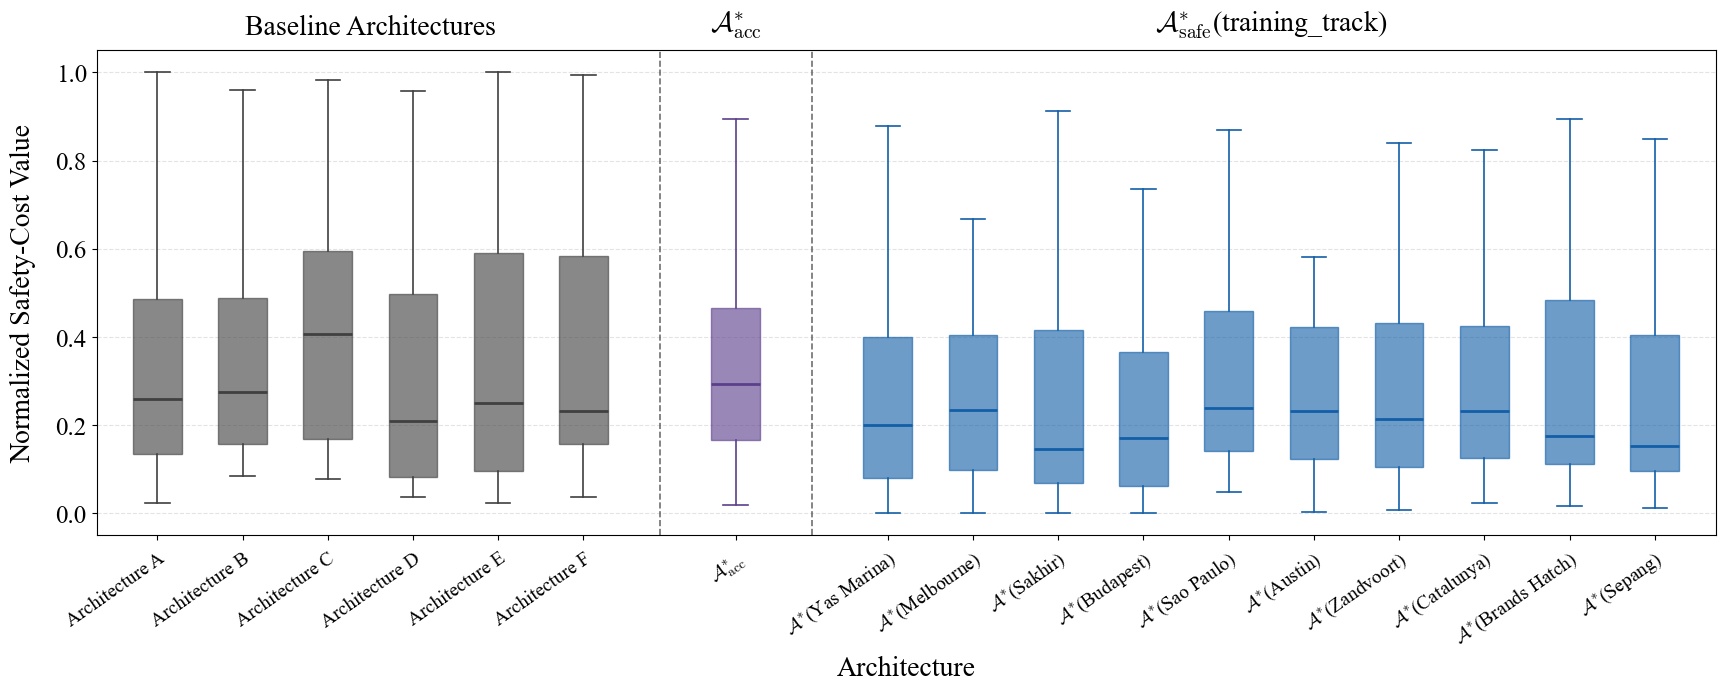

In [30]:
# Safety-NAS-style grouped composite boxplot: baseline architectures left, Accuracy-NAS center,
# Safety-NAS training-track runs right.

def plot_baseline_accuracy_safety_composite_boxplot(
    metric_keys: list[str],
    title: str | None = None,
    ylabel: str = "Normalized Safety-Cost Value",

    # Change save_stem to save figures
    save_stem: str | None = None,
    
) -> None:
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Latin Modern Roman", "Times New Roman", "Times"],
            "font.size": 18,
            "axes.labelsize": 20,
            "axes.titlesize": 20,
            "xtick.labelsize": 14,
            "ytick.labelsize": 18,
            "mathtext.fontset": "cm",
        }
    )

    metric_df = comparison_metric_values(metric_keys).copy()

    baseline_arches = [arch for arch in BASELINE_ARCHES if arch in set(metric_df["arch"])]
    safety_run_labels = [
        run_dir.name
        for run_dir in SAFETY_NAS_RUN_DIRS
        if not metric_df[
            (metric_df["model_group"] == SAFETY_NAS_LABEL)
            & (metric_df["run_dir"] == run_dir.name)
        ].empty
    ]
    accuracy_values = metric_df.loc[
        metric_df["model_group"] == ACCURACY_NAS_LABEL,
        "normalized_value",
    ].dropna().to_numpy()

    baseline_display_labels = {
        arch: f"Architecture {chr(ord('A') + idx)}"
        for idx, arch in enumerate(baseline_arches)
    }
    accuracy_display_label = r"$\mathcal{A}_{\mathrm{acc}}^{*}$"
    safety_display_labels = {
        run_label: rf"$\mathcal{{A}}^{{*}}$({TRAINED_MAP_LABELS.get(run_label, run_label)})"
        for run_label in safety_run_labels
    }

    box_width = 0.40
    edge_gap = 0.30
    group_gap = 0.85
    box_step = box_width + edge_gap

    baseline_positions = np.arange(len(baseline_arches), dtype=float) * box_step
    accuracy_position = (
        baseline_positions[-1] + box_width / 2 + group_gap + box_width / 2
        if len(baseline_positions)
        else 0.0
    )
    safety_start = accuracy_position + box_width / 2 + group_gap + box_width / 2
    safety_positions = safety_start + np.arange(len(safety_run_labels), dtype=float) * box_step

    baseline_position_lookup = dict(zip(baseline_arches, baseline_positions))
    safety_position_lookup = dict(zip(safety_run_labels, safety_positions))

    n_boxes = len(baseline_arches) + (1 if accuracy_values.size else 0) + len(safety_run_labels)
    fig_width = max(14, 0.82 * max(n_boxes, 1) + 3.2)
    fig, ax = plt.subplots(figsize=(fig_width, 6.8), constrained_layout=True)

    baseline_color = plt.cm.Greys(0.80)
    accuracy_color = "#5b3f8c"
    safety_color = plt.cm.Blues(0.82)

    def draw_box(values: np.ndarray, position: float, color) -> None:
        if values.size == 0:
            return
        ax.boxplot(
            [values],
            positions=[position],
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            boxprops={"facecolor": color, "edgecolor": color, "alpha": 0.62},
            medianprops={"color": color, "linewidth": 2.0},
            whiskerprops={"color": color, "linewidth": 1.2},
            capprops={"color": color, "linewidth": 1.2},
        )

    for arch in baseline_arches:
        values = metric_df.loc[
            (metric_df["model_group"] == BASELINE_LABEL) & (metric_df["arch"] == arch),
            "normalized_value",
        ].dropna().to_numpy()
        draw_box(values, baseline_position_lookup[arch], baseline_color)

    if accuracy_values.size:
        draw_box(accuracy_values, accuracy_position, accuracy_color)

    for run_label in safety_run_labels:
        values = metric_df.loc[
            (metric_df["model_group"] == SAFETY_NAS_LABEL)
            & (metric_df["run_dir"] == run_label),
            "normalized_value",
        ].dropna().to_numpy()
        draw_box(values, safety_position_lookup[run_label], safety_color)

    separator_positions = []
    if len(baseline_positions) and accuracy_values.size:
        separator_positions.append((baseline_positions[-1] + accuracy_position) / 2)
    if accuracy_values.size and len(safety_positions):
        separator_positions.append((accuracy_position + safety_positions[0]) / 2)
    for separator_x in separator_positions:
        ax.axvline(separator_x, color="0.25", linewidth=1.2, linestyle="--", alpha=0.75)

    if len(baseline_positions):
        ax.text(
            baseline_positions.mean(),
            1.02,
            "Baseline Architectures",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=20,
        )
    if accuracy_values.size:
        ax.text(
            accuracy_position,
            1.02,
            accuracy_display_label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=20,
            color="black",
        )
    if len(safety_positions):
        ax.text(
            safety_positions.mean(),
            1.02,
            r"$\mathcal{A}_{\mathrm{safe}}^{*}$(training_track)",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=20,
            color="black",
        )

    tick_positions = [baseline_position_lookup[arch] for arch in baseline_arches]
    tick_labels = [baseline_display_labels[arch] for arch in baseline_arches]
    if accuracy_values.size:
        tick_positions.append(accuracy_position)
        tick_labels.append(accuracy_display_label)
    tick_positions.extend([safety_position_lookup[run_label] for run_label in safety_run_labels])
    tick_labels.extend([safety_display_labels[run_label] for run_label in safety_run_labels])

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=35, ha="right", rotation_mode="anchor")
    ax.tick_params(axis="x", labelsize=14, pad=6)
    ax.tick_params(axis="y", labelsize=18)
    ax.set_ylabel(ylabel, labelpad=14)
    ax.set_xlabel("Architecture")
    # Intentionally no title; the figure is labeled in the manuscript.
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    all_positions = np.array(tick_positions, dtype=float)
    if all_positions.size:
        ax.set_xlim(
            all_positions.min() - box_width / 2 - edge_gap,
            all_positions.max() + box_width / 2 + edge_gap,
        )

    if save_stem:
        save_root = REPO_ROOT
        pdf_path = save_root / f"{save_stem}.pdf"
        svg_path = save_root / f"{save_stem}.svg"
        fig.savefig(pdf_path, bbox_inches="tight")
        fig.savefig(svg_path, bbox_inches="tight")
        print(f"Saved grouped composite plot to {pdf_path}")
        print(f"Saved editable grouped composite plot to {svg_path}")



plot_baseline_accuracy_safety_composite_boxplot(
    EVALUATED_METRICS,
)
